## A short notebook tutorial on Spherical Harmonic (Ridge) Regression

Last Modified: July 13th, 2024
Author: Opal Issan (PhD student @UCSD). contact: oissan@ucsd.edu

In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np 
import pandas as pd
import scipy
import geopandas
import geodatasets
import cartopy
from supermag_api import * 
from spherical_harmonics import get_spherical_harmonic_basis_matrix, ridge_regression, construct_global_view

In [3]:
import matplotlib.pyplot as plt
import matplotlib
from mycolorpy import colorlist as mcp
font = {'family' : 'serif',
        'size'   : 14}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 

## Spherical Harmonics Regression 

In [4]:
# number of data points
N = 5
# order of spherical harmonic interpolator 
ell = 5
# ridge regression regularization 
lambda_ = 0.01

In [5]:
# latitude samples
theta_sample = np.linspace(0, np.pi, N, endpoint=False)
# longitude samples
phi_sample = np.linspace(0, 2*np.pi, N, endpoint=False)
# data at the (theta, phi) locations
data = np.random.random(N)

In [6]:
Y = get_spherical_harmonic_basis_matrix(latitude=theta_sample, longitude=phi_sample, ell=ell)

In [7]:
pred = construct_global_view(coeff=ridge_regression(basis_matrix=Y, data=data, lambda_=lambda_), 
                             longitude=phi_sample, 
                             latitude=theta_sample)

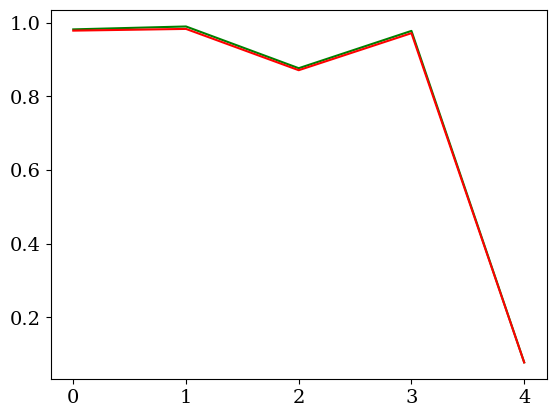

In [8]:
plt.plot(data, color="green")
plt.plot(pred, color="red")

# SuperMAG data

In [9]:
# start date year-month-day-hour-min-sec
start=[2019,5,1,10,40,00] 

In [10]:
# read in data
(status,stations) = SuperMAGGetInventory("opaliss", start, 3600)
# number of stations
N = len(stations)
print("number of stations = ", N)

number of stations =  199


In [11]:
# intialize data
data_Bn = np.zeros(N)
geo_lat = np.zeros(N)
geo_lon = np.zeros(N)

In [12]:
# read in data for 1hr in advance from start date at station "res"
for ii in range(N):
    (status, sm_data) = SuperMAGGetData("opaliss", start, 3600,'geo', stations[ii])
    data_Bn[ii] = sm_data.N[0]["geo"]
    geo_lat[ii] = sm_data.glat[0] 
    geo_lon[ii] = sm_data.glon[0]

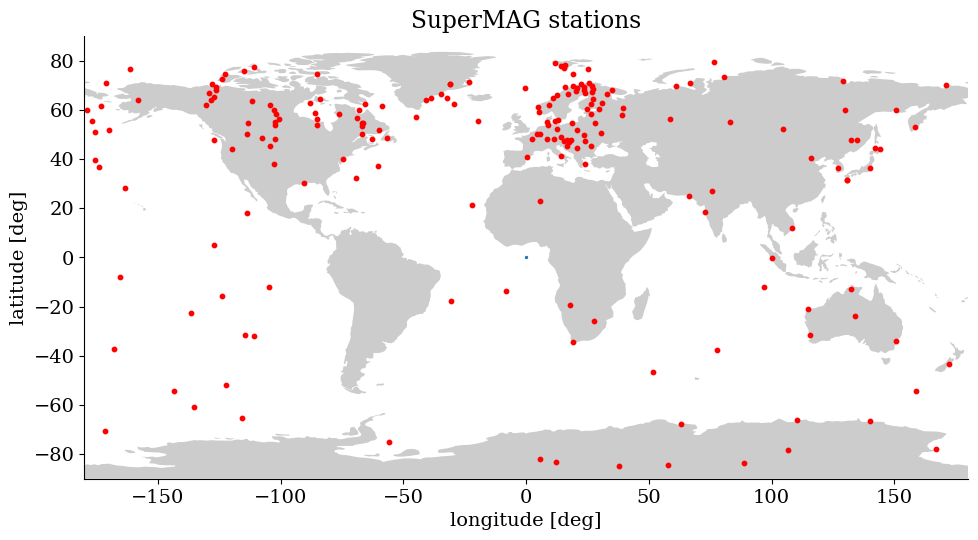

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
path = geodatasets.get_path("naturalearth.land")
df = geopandas.read_file(path)
df.plot(ax=ax, alpha=0.4, color="grey")

for ii in range(N):
    if geo_lon[ii] > 180:
        plt.scatter(180-geo_lon[ii], geo_lat[ii], color="red", s=10)
    else:
        plt.scatter(geo_lon[ii], geo_lat[ii], color="red", s=10)
_ = plt.title("SuperMAG stations")
ax.scatter(0, 0, s=2)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
plt.tight_layout()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig("figures/supermag_stations.png", bbox_inches='tight', dpi=600)

## Spherical Harmonics Regression 

In [205]:
# order of spherical harmonic interpolator 
ell = 40
# ridge regression regularization 
lambda_ = 0.1

In [206]:
Y = get_spherical_harmonic_basis_matrix(latitude=geo_lat*np.pi/180, longitude=geo_lon*np.pi/180, ell=ell)

In [207]:
pred = construct_global_view(coeff=ridge_regression(basis_matrix=Y, data=data_Bn, lambda_=lambda_), 
                             longitude=geo_lon*np.pi/180, latitude=geo_lat*np.pi/180)

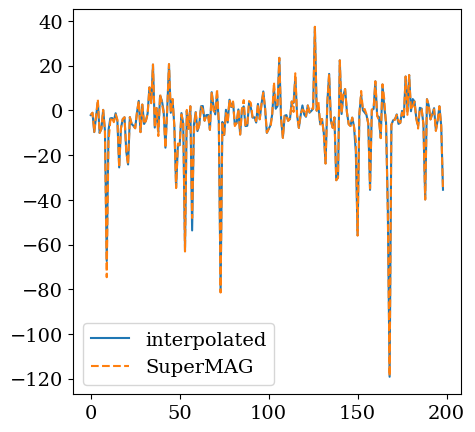

In [208]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(pred, label="interpolated")
ax.plot(data_Bn, ls="--", label="SuperMAG")
plt.legend()

In [209]:
N_interp = 600
THETA, PHI = np.meshgrid(np.linspace(0, 180, N_interp), np.linspace(0, 360, N_interp))

In [210]:
pred = construct_global_view(coeff=ridge_regression(basis_matrix=Y, data=data_Bn, lambda_=lambda_), 
                             longitude=np.ndarray.flatten(PHI)*np.pi/180, latitude=np.ndarray.flatten(THETA)*np.pi/180)

In [211]:
PHI[np.where(PHI > 180)] = 180-PHI[np.where(PHI > 180)] 

/var/folders/tt/hgb4_vc13z77x5wpt5lzk5j40000gn/T/ipykernel_31285/3171202267.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pos = ax.pcolormesh(PHI, THETA-90, np.reshape(pred, (600, 600), order="C"), alpha=0.35, vmin=-50, vmax=50)


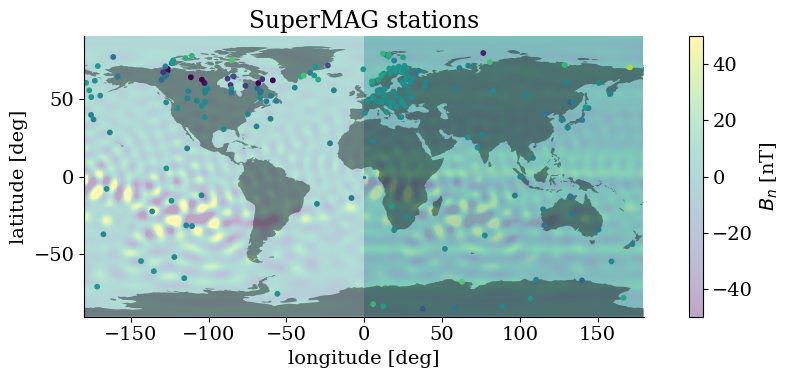

In [227]:
fig, ax = plt.subplots(figsize=(10, 4))
path = geodatasets.get_path("naturalearth.land")
df = geopandas.read_file(path)

pos = ax.pcolormesh(PHI, THETA-90, np.reshape(pred, (600, 600), order="C"), alpha=0.35, vmin=-50, vmax=50)
cbar = fig.colorbar(pos)
df.plot(ax=ax, alpha=0.4, color="black")
_ = plt.title("SuperMAG stations")

plt.scatter(geo_lon, geo_lat, c=data_Bn, s=10, cmap='viridis', vmin=-50, vmax=50)
plt.scatter(180-geo_lon[np.where(geo_lon>180)], geo_lat[np.where(geo_lon>180)], c=data_Bn[np.where(geo_lon>180)], s=10, cmap='viridis', vmin=-50, vmax=50)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.scatter(0, 0, s=2)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/supermag_stations.png", bbox_inches='tight', dpi=600)